In [1]:
import os

os.chdir(r"C:\Users\HP USER\OneDrive\Desktop\transfer-learning-kaduna-house-price")

print("Current folder:", os.getcwd())
print("Files in data folder:", os.listdir("data"))

Current folder: C:\Users\HP USER\OneDrive\Desktop\transfer-learning-kaduna-house-price
Files in data folder: ['data_kaggle.csv', 'Strict_Kaduna_South_Dataset.csv']


Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 150

print("Libraries imported successfully.")

Libraries imported successfully.


 Load Original Raw Datasets

In [3]:
# Load original raw datasets before any preprocessing
malaysia_raw = pd.read_csv("data/data_kaggle.csv")
kaduna_raw   = pd.read_csv("data/Strict_Kaduna_South_Dataset.csv")

print("Datasets loaded successfully.")
print(f"\nMalaysia shape : {malaysia_raw.shape}")
print(f"Kaduna shape   : {kaduna_raw.shape}")

Datasets loaded successfully.

Malaysia shape : (53883, 8)
Kaduna shape   : (37, 11)


Malaysia Basic Information

In [4]:
print("=" * 55)
print("     MALAYSIA DATASET — BASIC INFORMATION")
print("=" * 55)

print(f"\nTotal records  : {malaysia_raw.shape[0]:,}")
print(f"Total features : {malaysia_raw.shape[1]}")

print("\nColumn names and data types:")
print(malaysia_raw.dtypes)

print("\nFirst 5 rows:")
print(malaysia_raw.head())

     MALAYSIA DATASET — BASIC INFORMATION

Total records  : 53,883
Total features : 8

Column names and data types:
Location             str
Price                str
Rooms                str
Bathrooms        float64
Car Parks        float64
Property Type        str
Size                 str
Furnishing           str
dtype: object

First 5 rows:
                          Location         Price Rooms  Bathrooms  Car Parks  \
0               KLCC, Kuala Lumpur  RM 1,250,000   2+1        3.0        2.0   
1  Damansara Heights, Kuala Lumpur  RM 6,800,000     6        7.0        NaN   
2            Dutamas, Kuala Lumpur  RM 1,030,000     3        4.0        2.0   
3             Cheras, Kuala Lumpur           NaN   NaN        NaN        NaN   
4        Bukit Jalil, Kuala Lumpur    RM 900,000   4+1        3.0        2.0   

          Property Type                      Size        Furnishing  
0    Serviced Residence  Built-up : 1,335 sq. ft.   Fully Furnished  
1              Bungalow  Land area

Kaduna Basic Information

In [5]:
print("=" * 55)
print("     KADUNA DATASET — BASIC INFORMATION")
print("=" * 55)

print(f"\nTotal records  : {kaduna_raw.shape[0]:,}")
print(f"Total features : {kaduna_raw.shape[1]}")

print("\nColumn names and data types:")
print(kaduna_raw.dtypes)

print("\nFirst 5 rows:")
print(kaduna_raw.head())

     KADUNA DATASET — BASIC INFORMATION

Total records  : 37
Total features : 11

Column names and data types:
Property_Type      str
Bedrooms         int64
Bathrooms        int64
Size_sqm         int64
Location           str
LGA                str
Condition          str
Security           str
Flood_Risk         str
Proximity          str
Price            int64
dtype: object

First 5 rows:
  Property_Type  Bedrooms  Bathrooms  Size_sqm Location           LGA  \
0      Bungalow         3          2       140  Barnawa  Kaduna South   
1      Bungalow         3          2       150  Barnawa  Kaduna South   
2      Bungalow         3          2       135  Barnawa  Kaduna South   
3      Bungalow         3          2       145  Barnawa  Kaduna South   
4          Flat         2          2       100   Kakuri  Kaduna South   

  Condition Security Flood_Risk Proximity     Price  
0       New     High        Low      Near  48000000  
1       New     High        Low      Near  52000000  
2     

Malaysia Statistical Summary

In [6]:
print("=" * 55)
print("   MALAYSIA DATASET — STATISTICAL SUMMARY")
print("=" * 55)

print("\nDescriptive statistics:")
print(malaysia_raw.describe().round(2))

   MALAYSIA DATASET — STATISTICAL SUMMARY

Descriptive statistics:
       Bathrooms  Car Parks
count   51870.00   36316.00
mean        3.07       2.01
std         1.63       1.31
min         1.00       1.00
25%         2.00       1.00
50%         2.00       2.00
75%         4.00       2.00
max        20.00      30.00


 Kaduna Statistical Summary

In [7]:
print("=" * 55)
print("    KADUNA DATASET — STATISTICAL SUMMARY")
print("=" * 55)

print("\nDescriptive statistics:")
print(kaduna_raw.describe().round(2))

    KADUNA DATASET — STATISTICAL SUMMARY

Descriptive statistics:
       Bedrooms  Bathrooms  Size_sqm         Price
count     37.00      37.00     37.00  3.700000e+01
mean       2.62       2.38    147.70  4.616216e+07
std        1.30       1.30    132.52  6.200885e+07
min        1.00       1.00     35.00  2.500000e+06
25%        2.00       2.00     90.00  1.500000e+07
50%        2.00       2.00    110.00  2.600000e+07
75%        3.00       3.00    145.00  4.500000e+07
max        7.00       7.00    800.00  3.500000e+08


Missing Values for Malaysia

In [8]:
print("=" * 55)
print("    MALAYSIA DATASET — MISSING VALUES")
print("=" * 55)

malaysia_missing = malaysia_raw.isnull().sum()
malaysia_missing_pct = (malaysia_missing /
                        len(malaysia_raw) * 100).round(2)

malaysia_missing_df = pd.DataFrame({
    'Missing Count': malaysia_missing,
    'Missing (%)': malaysia_missing_pct
})

print(malaysia_missing_df)
print(f"\nTotal missing values: "
      f"{malaysia_raw.isnull().sum().sum()}")

    MALAYSIA DATASET — MISSING VALUES
               Missing Count  Missing (%)
Location                   0         0.00
Price                    248         0.46
Rooms                   1706         3.17
Bathrooms               2013         3.74
Car Parks              17567        32.60
Property Type             25         0.05
Size                    1063         1.97
Furnishing              6930        12.86

Total missing values: 29552


 Missing Values for Kaduna

In [9]:
print("=" * 55)
print("     KADUNA DATASET — MISSING VALUES")
print("=" * 55)

kaduna_missing = kaduna_raw.isnull().sum()
kaduna_missing_pct = (kaduna_missing /
                      len(kaduna_raw) * 100).round(2)

kaduna_missing_df = pd.DataFrame({
    'Missing Count': kaduna_missing,
    'Missing (%)': kaduna_missing_pct
})

print(kaduna_missing_df)
print(f"\nTotal missing values: "
      f"{kaduna_raw.isnull().sum().sum()}")

     KADUNA DATASET — MISSING VALUES
               Missing Count  Missing (%)
Property_Type              0          0.0
Bedrooms                   0          0.0
Bathrooms                  0          0.0
Size_sqm                   0          0.0
Location                   0          0.0
LGA                        0          0.0
Condition                  0          0.0
Security                   0          0.0
Flood_Risk                 0          0.0
Proximity                  0          0.0
Price                      0          0.0

Total missing values: 0


 Duplicate Check for Both Datasets

In [10]:
print("=" * 55)
print("          DUPLICATE RECORDS CHECK")
print("=" * 55)

malaysia_dups = malaysia_raw.duplicated().sum()
kaduna_dups   = kaduna_raw.duplicated().sum()

print(f"\nMalaysia duplicate rows : {malaysia_dups}")
print(f"Kaduna duplicate rows   : {kaduna_dups}")

if malaysia_dups > 0:
    print("\nMalaysia duplicates will be removed.")
if kaduna_dups > 0:
    print("\nKaduna duplicates will be removed.")
if malaysia_dups == 0 and kaduna_dups == 0:
    print("\nNo duplicates found in either dataset.")

          DUPLICATE RECORDS CHECK

Malaysia duplicate rows : 4467
Kaduna duplicate rows   : 0

Malaysia duplicates will be removed.


In [11]:
print("Malaysia raw columns:")
print(malaysia_raw.columns.tolist())

print("\nKaduna raw columns:")
print(kaduna_raw.columns.tolist())

Malaysia raw columns:
['Location', 'Price', 'Rooms', 'Bathrooms', 'Car Parks', 'Property Type', 'Size', 'Furnishing']

Kaduna raw columns:
['Property_Type', 'Bedrooms', 'Bathrooms', 'Size_sqm', 'Location', 'LGA', 'Condition', 'Security', 'Flood_Risk', 'Proximity', 'Price']


Clean Malaysia Price Column First

In [12]:
# Check what Malaysia price looks like
print("Malaysia Price sample:")
print(malaysia_raw['Price'].head(10))
print("\nData type:", malaysia_raw['Price'].dtype)

Malaysia Price sample:
0    RM 1,250,000
1    RM 6,800,000
2    RM 1,030,000
3             NaN
4      RM 900,000
5    RM 5,350,000
6             NaN
7    RM 2,600,000
8    RM 1,950,000
9      RM 385,000
Name: Price, dtype: str

Data type: str


Convert Malaysia Price to Numbers
python

In [13]:
# Remove "RM" and commas then convert to float
malaysia_raw['Price_clean'] = (
    malaysia_raw['Price']
    .str.replace('RM', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.strip()
    .astype(float)
)

print("Malaysia price after cleaning:")
print(malaysia_raw['Price_clean'].head(10))
print(f"\nData type : {malaysia_raw['Price_clean'].dtype}")
print(f"Min price : {malaysia_raw['Price_clean'].min():,.0f} MYR")
print(f"Max price : {malaysia_raw['Price_clean'].max():,.0f} MYR")
print(f"Mean price: {malaysia_raw['Price_clean'].mean():,.0f} MYR")

Malaysia price after cleaning:
0    1250000.0
1    6800000.0
2    1030000.0
3          NaN
4     900000.0
5    5350000.0
6          NaN
7    2600000.0
8    1950000.0
9     385000.0
Name: Price_clean, dtype: float64

Data type : float64
Min price : 10 MYR
Max price : 1,980,000,000 MYR
Mean price: 2,091,947 MYR


Malaysia Price Distribution (Fixed)

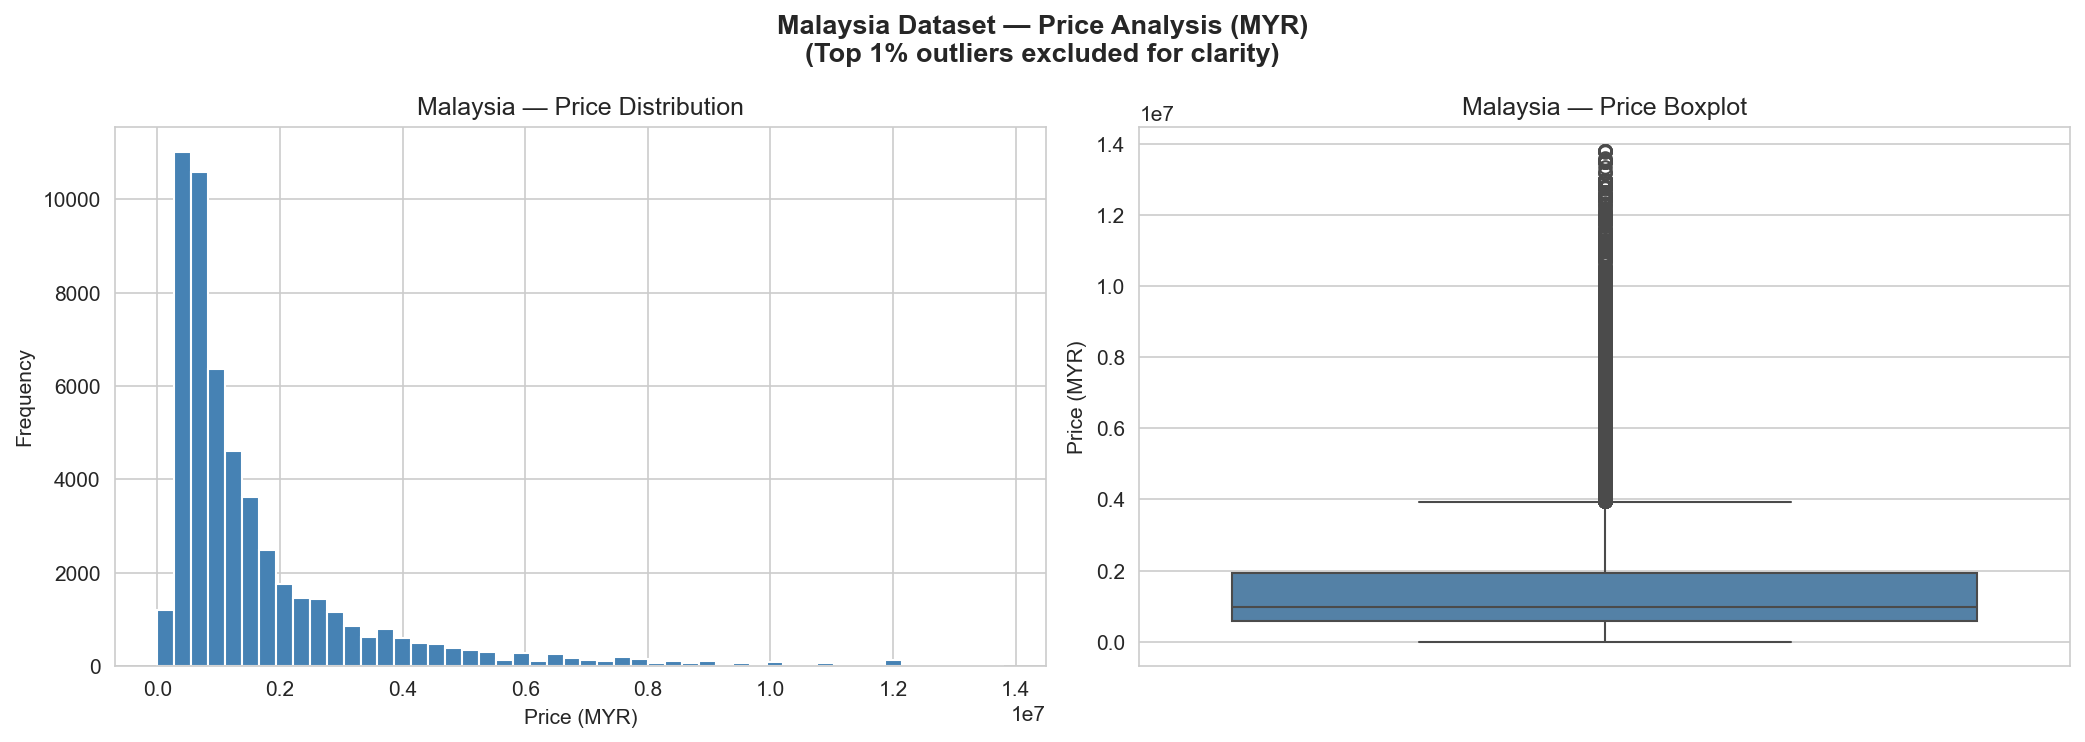

Chart saved.


In [14]:
p99 = malaysia_raw['Price_clean'].quantile(0.99)

malaysia_price_clean = malaysia_raw['Price_clean'].dropna()
malaysia_price_clean = malaysia_price_clean[
    malaysia_price_clean <= p99]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(malaysia_price_clean,
             bins=50,
             color='steelblue',
             edgecolor='white')
axes[0].set_title("Malaysia — Price Distribution")
axes[0].set_xlabel("Price (MYR)")
axes[0].set_ylabel("Frequency")

# Boxplot
sns.boxplot(y=malaysia_price_clean,
            ax=axes[1],
            color='steelblue')
axes[1].set_title("Malaysia — Price Boxplot")
axes[1].set_ylabel("Price (MYR)")

plt.suptitle(
    "Malaysia Dataset — Price Analysis (MYR)\n"
    "(Top 1% outliers excluded for clarity)",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_malaysia_price.png", dpi=150)
plt.show()
print("Chart saved.")

Kaduna Price Distribution

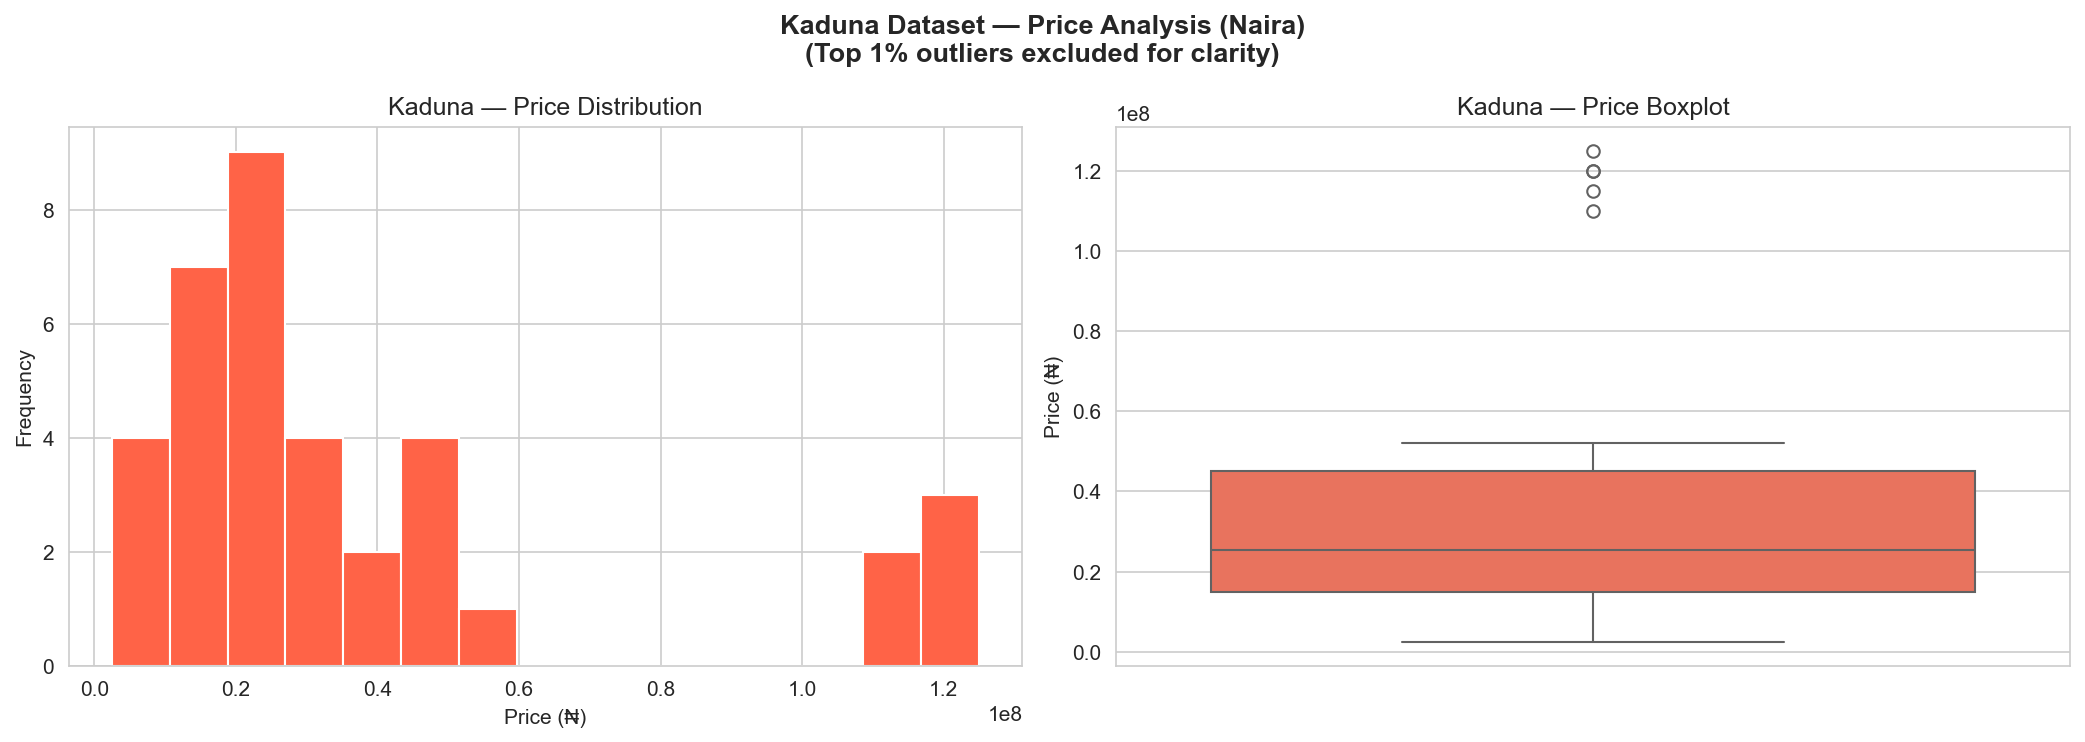

Chart saved.


In [15]:
p99_kaduna = kaduna_raw['Price'].quantile(0.99)

kaduna_price_clean = kaduna_raw['Price'].dropna()
kaduna_price_clean = kaduna_price_clean[
    kaduna_price_clean <= p99_kaduna]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(kaduna_price_clean,
             bins=15,
             color='tomato',
             edgecolor='white')
axes[0].set_title("Kaduna — Price Distribution")
axes[0].set_xlabel("Price (₦)")
axes[0].set_ylabel("Frequency")

# Boxplot
sns.boxplot(y=kaduna_price_clean,
            ax=axes[1],
            color='tomato')
axes[1].set_title("Kaduna — Price Boxplot")
axes[1].set_ylabel("Price (₦)")

plt.suptitle(
    "Kaduna Dataset — Price Analysis (Naira)\n"
    "(Top 1% outliers excluded for clarity)",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_kaduna_price.png", dpi=150)
plt.show()
print("Chart saved.")

Malaysia Categorical Features

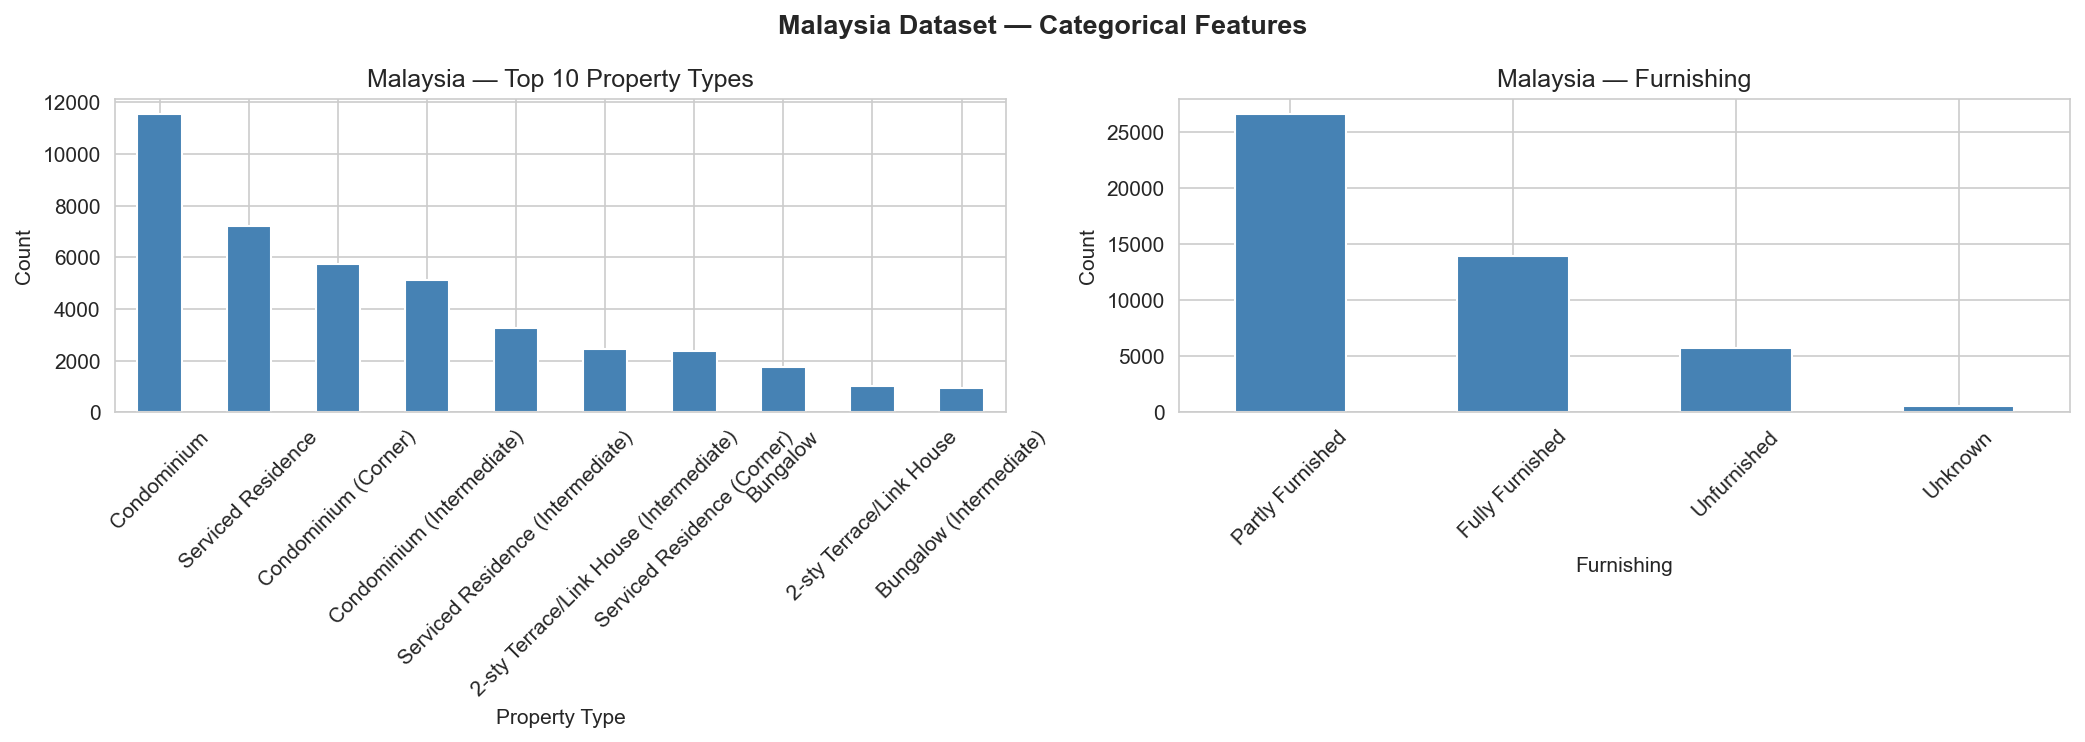

Chart saved.


In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Top 10 Property Types only
malaysia_raw['Property Type'].value_counts()\
    .head(10).plot(
    kind='bar',
    ax=axes[0],
    color='steelblue',
    edgecolor='white')
axes[0].set_title("Malaysia — Top 10 Property Types")
axes[0].set_xlabel("Property Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Furnishing
malaysia_raw['Furnishing'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color='steelblue',
    edgecolor='white')
axes[1].set_title("Malaysia — Furnishing")
axes[1].set_xlabel("Furnishing")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    "Malaysia Dataset — Categorical Features",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_malaysia_categorical.png", dpi=150)
plt.show()
print("Chart saved.")

 Kaduna Categorical Features

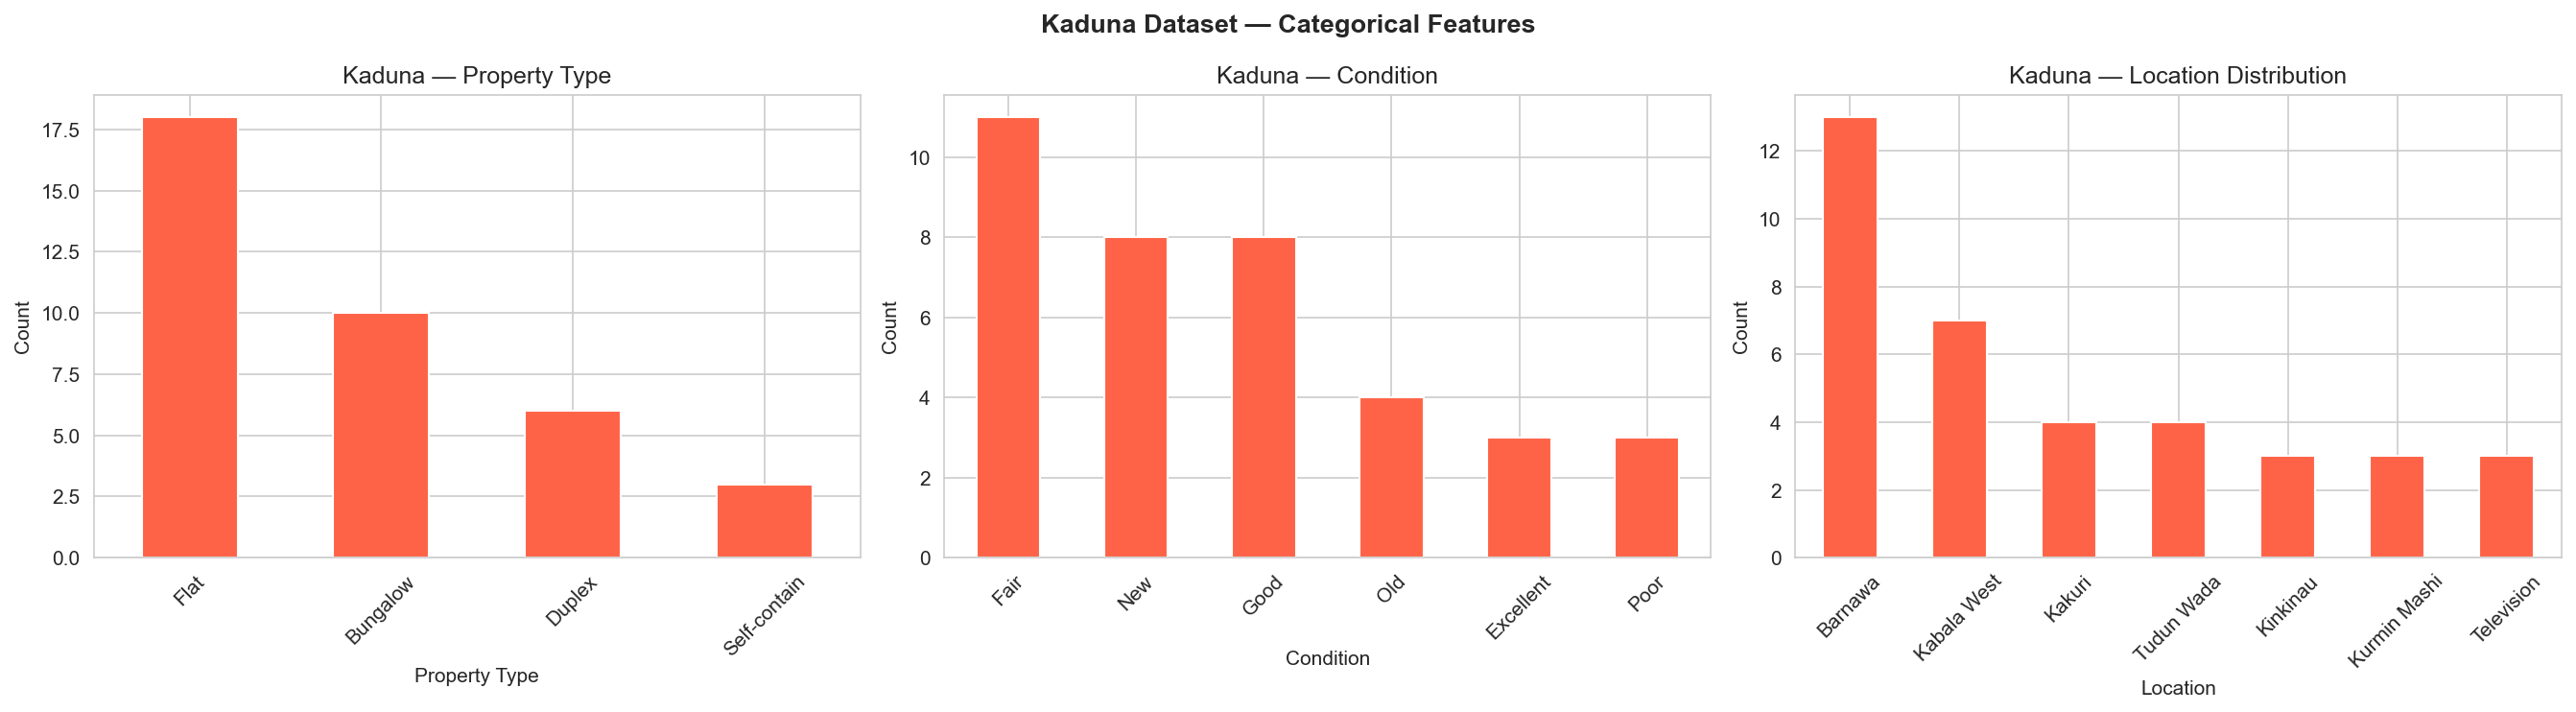

Chart saved.


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Property Type
kaduna_raw['Property_Type'].value_counts().plot(
    kind='bar',
    ax=axes[0],
    color='tomato',
    edgecolor='white')
axes[0].set_title("Kaduna — Property Type")
axes[0].set_xlabel("Property Type")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Condition
kaduna_raw['Condition'].value_counts().plot(
    kind='bar',
    ax=axes[1],
    color='tomato',
    edgecolor='white')
axes[1].set_title("Kaduna — Condition")
axes[1].set_xlabel("Condition")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

# Location
kaduna_raw['Location'].value_counts().plot(
    kind='bar',
    ax=axes[2],
    color='tomato',
    edgecolor='white')
axes[2].set_title("Kaduna — Location Distribution")
axes[2].set_xlabel("Location")
axes[2].set_ylabel("Count")
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle(
    "Kaduna Dataset — Categorical Features",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_kaduna_categorical.png", dpi=150)
plt.show()
print("Chart saved.")

Kaduna Price by Location

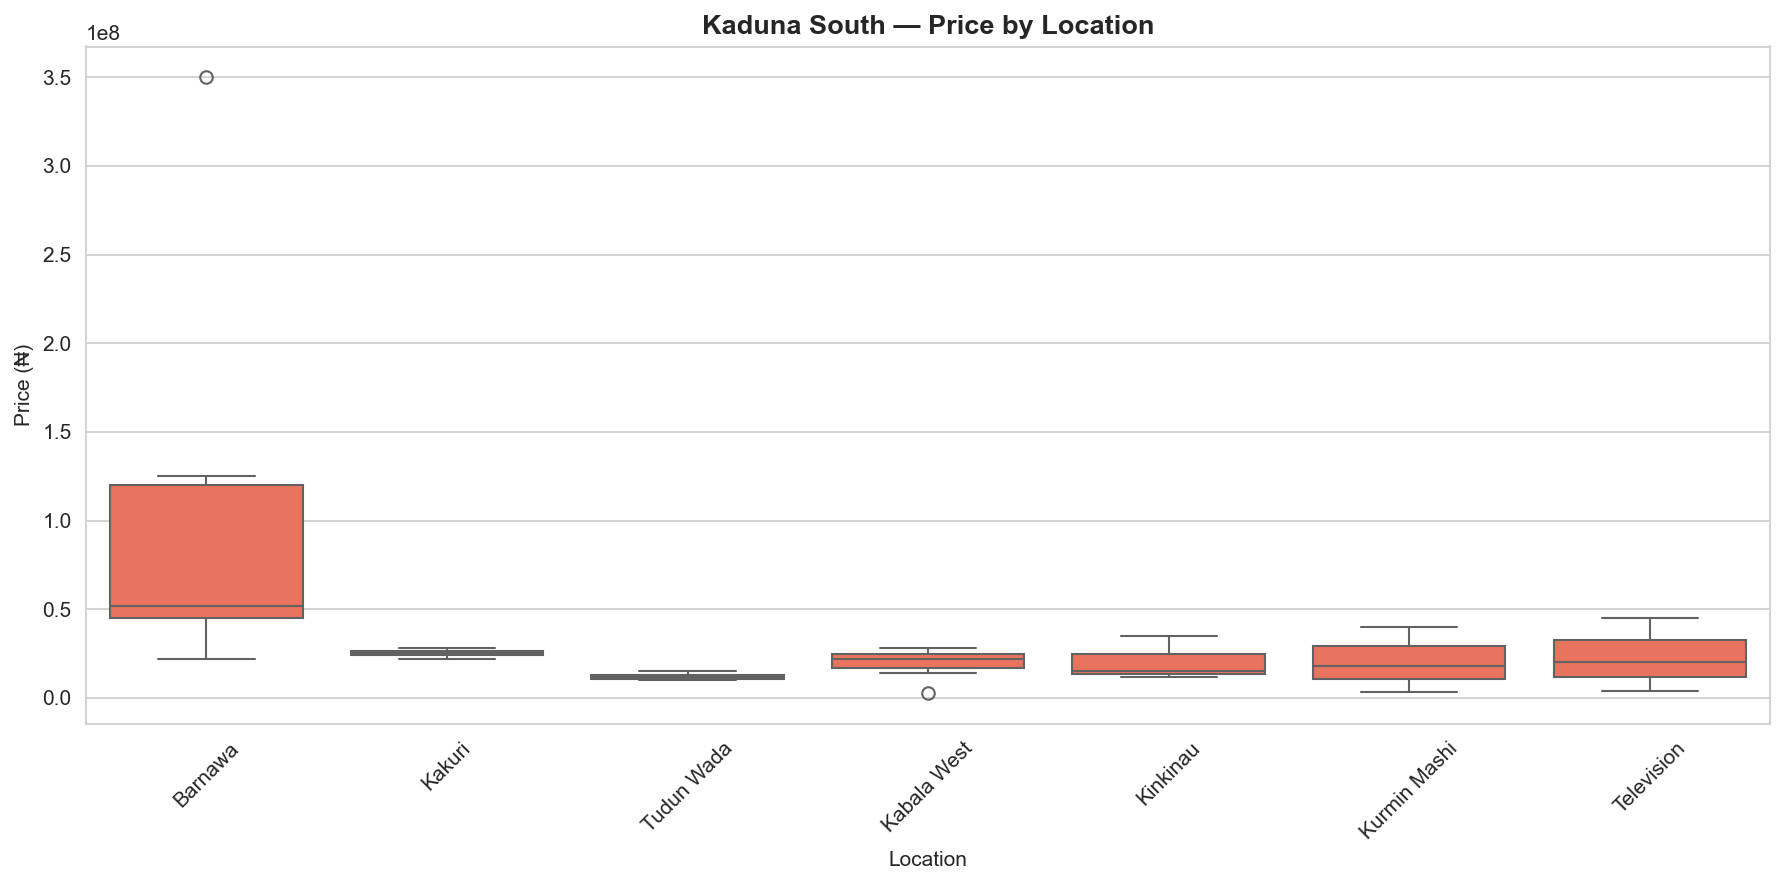

Chart saved.


In [18]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=kaduna_raw,
    x='Location',
    y='Price',
    ax=ax,
    color='tomato')

ax.set_title(
    "Kaduna South — Price by Location",
    fontsize=13, fontweight='bold')
ax.set_xlabel("Location")
ax.set_ylabel("Price (₦)")
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("eda_kaduna_price_location.png", dpi=150)
plt.show()
print("Chart saved.")

 Extract Size Numbers from Malaysia

In [31]:
import re

def extract_size_better(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).replace(',', '')
    
    # Handle multiplication format like "25x75" or "22 x 80"
    mult_match = re.search(
        r'(\d+\.?\d*)\s*[xX]\s*(\d+\.?\d*)', value)
    if mult_match:
        return float(mult_match.group(1)) * \
               float(mult_match.group(2))
    
    # Handle plain numbers
    plain_match = re.search(r'(\d+\.?\d*)', value)
    if plain_match:
        return float(plain_match.group(1))
    
    return np.nan

malaysia_raw['Size_clean'] = malaysia_raw['Size'].apply(
    extract_size_better)

# Remove invalid sizes
malaysia_raw.loc[
    malaysia_raw['Size_clean'] <= 0, 
    'Size_clean'] = np.nan

print("Size after better extraction:")
print(malaysia_raw['Size_clean'].dropna().head(15))
print(f"\nValid size records: "
      f"{malaysia_raw['Size_clean'].dropna().shape[0]}")
print(f"Min size : "
      f"{malaysia_raw['Size_clean'].min():,.0f} sq ft")
print(f"Max size : "
      f"{malaysia_raw['Size_clean'].max():,.0f} sq ft")
print(f"Mean size: "
      f"{malaysia_raw['Size_clean'].mean():,.0f} sq ft")

Size after better extraction:
0     1335.0
1     6900.0
2     1875.0
4     1513.0
5     7200.0
7     3600.0
8     1875.0
9      904.0
11    1760.0
12    1900.0
13    6000.0
15    3600.0
16    8500.0
17    4842.0
18    1830.0
Name: Size_clean, dtype: float64

Valid size records: 52679
Min size : 1 sq ft
Max size : 11,000,000 sq ft
Mean size: 2,887 sq ft


Malaysia Numerical Features Distribution

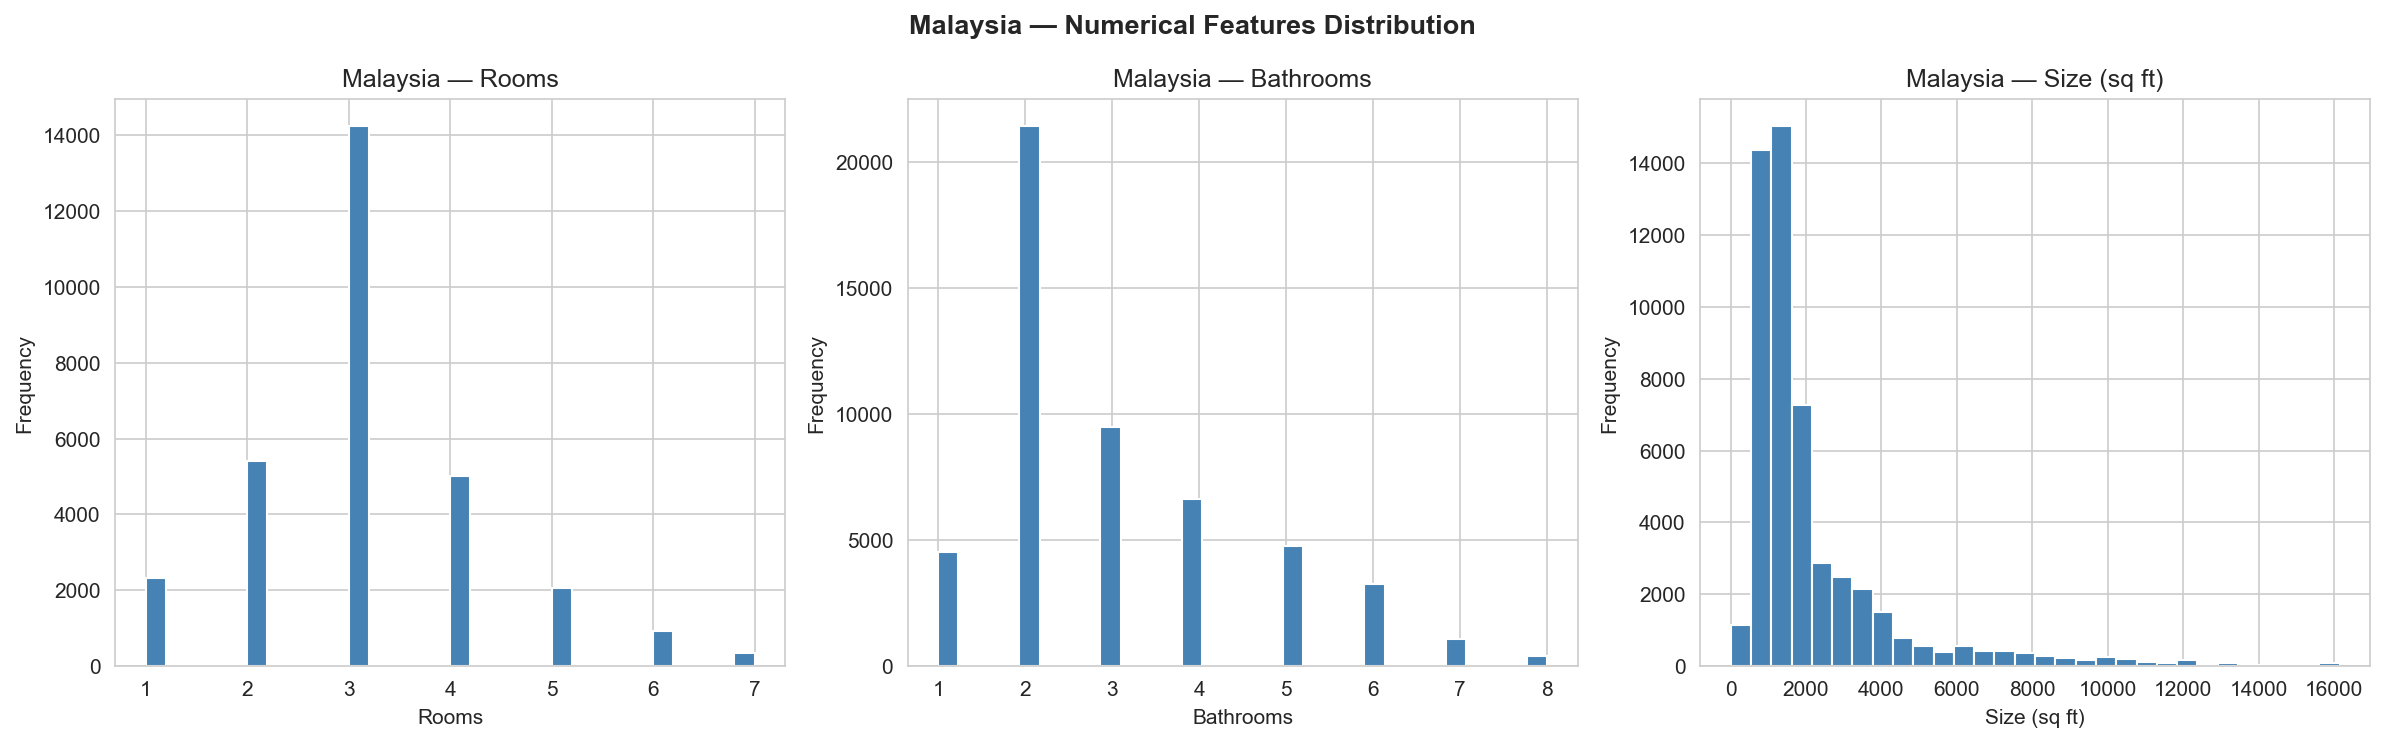

Chart saved.


In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

size_p99  = malaysia_raw['Size_clean'].quantile(0.99)
rooms_p99 = malaysia_raw['Rooms_clean'].quantile(0.99)
bath_p99  = malaysia_raw['Bathrooms'].quantile(0.99)

data = {
    'Rooms':        malaysia_raw['Rooms_clean'][
        malaysia_raw['Rooms_clean'] <= rooms_p99],
    'Bathrooms':    malaysia_raw['Bathrooms'][
        malaysia_raw['Bathrooms'] <= bath_p99],
    'Size (sq ft)': malaysia_raw['Size_clean'][
        malaysia_raw['Size_clean'] <= size_p99]
}

for i, (label, values) in enumerate(data.items()):
    axes[i].hist(
        values.dropna(),
        bins=30,
        color='steelblue',
        edgecolor='white')
    axes[i].set_title(f"Malaysia — {label}")
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Malaysia — Numerical Features Distribution",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_malaysia_numerical.png", dpi=150)
plt.show()
print("Chart saved.")

Malaysia Scatter Plots

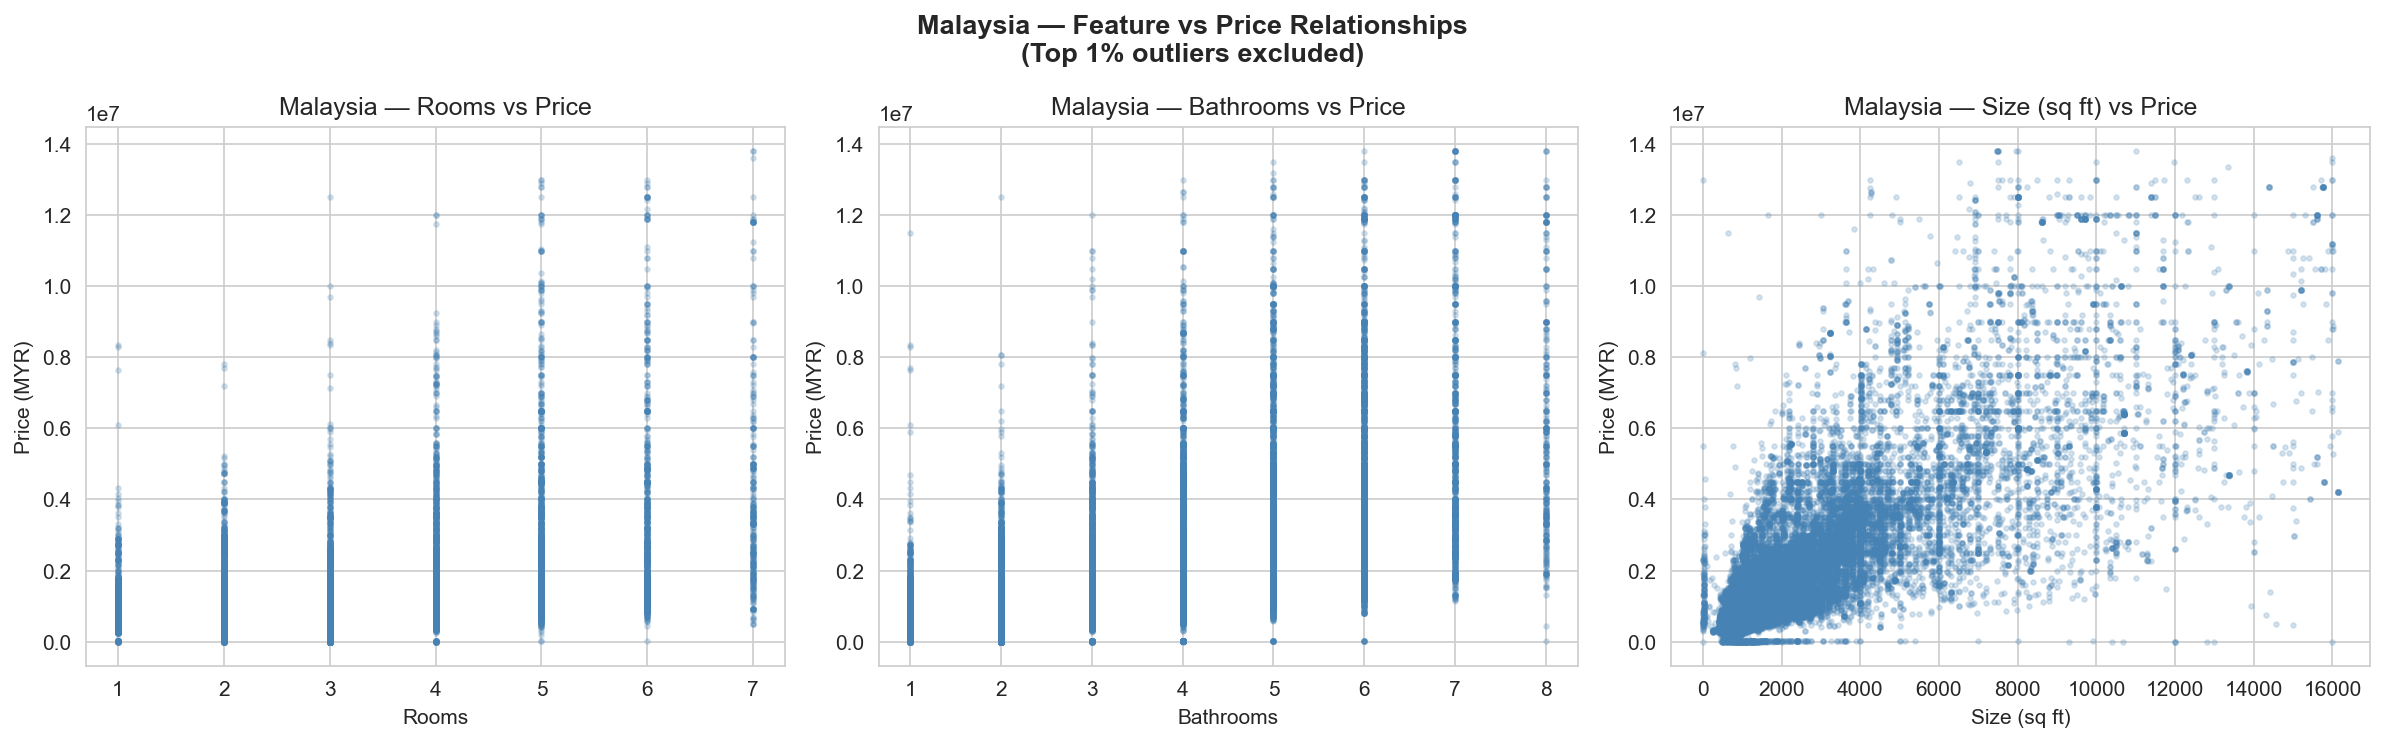

Chart saved.


In [33]:
price_p99 = malaysia_raw['Price_clean'].quantile(0.99)
size_p99  = malaysia_raw['Size_clean'].quantile(0.99)
rooms_p99 = malaysia_raw['Rooms_clean'].quantile(0.99)
bath_p99  = malaysia_raw['Bathrooms'].quantile(0.99)

malaysia_plot = malaysia_raw[
    malaysia_raw['Price_clean'] <= price_p99].copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

scatter_cols = {
    'Rooms':        ('Rooms_clean',  rooms_p99),
    'Bathrooms':    ('Bathrooms',    bath_p99),
    'Size (sq ft)': ('Size_clean',   size_p99)
}

for i, (label, (col, p99)) in enumerate(
        scatter_cols.items()):
    filtered = malaysia_plot[
        malaysia_plot[col] <= p99]
    axes[i].scatter(
        filtered[col],
        filtered['Price_clean'],
        alpha=0.2,
        color='steelblue',
        s=5)
    axes[i].set_title(
        f"Malaysia — {label} vs Price")
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Price (MYR)")

plt.suptitle(
    "Malaysia — Feature vs Price Relationships\n"
    "(Top 1% outliers excluded)",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_malaysia_scatter.png", dpi=150)
plt.show()
print("Chart saved.")

Malaysia Correlation Heatmap

Records for correlation: 29584


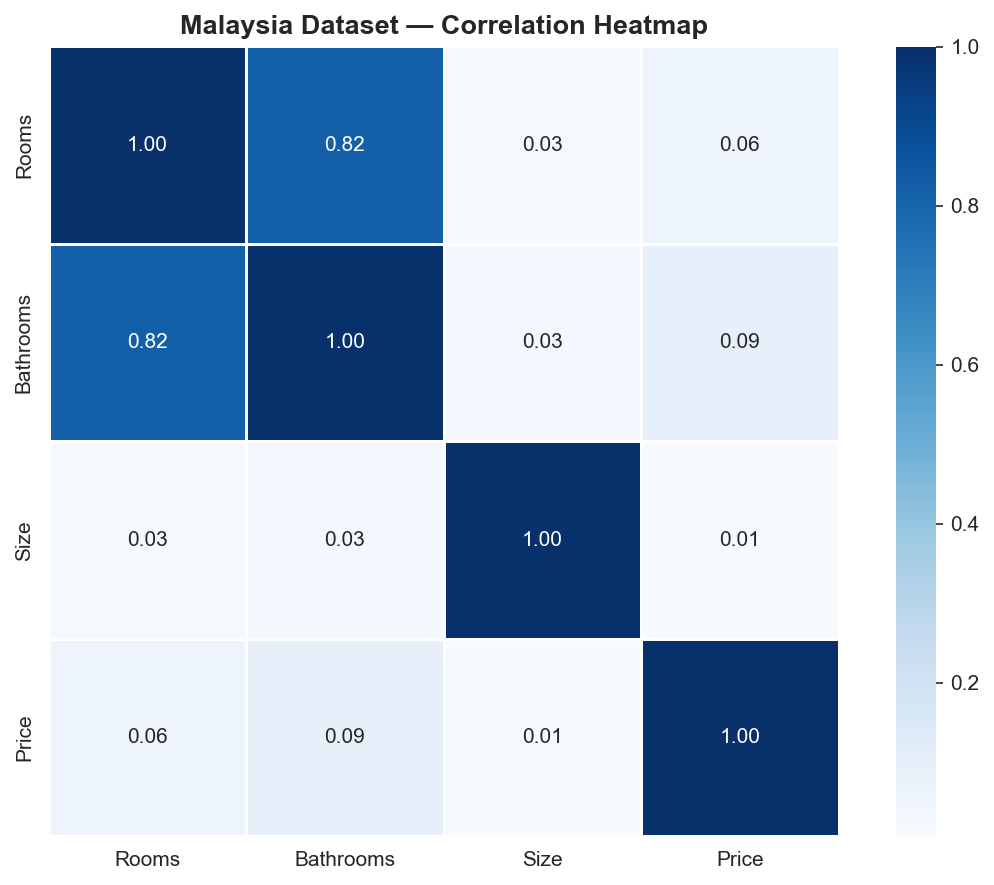

Chart saved.


In [34]:
malaysia_num = malaysia_raw[[
    'Rooms_clean',
    'Bathrooms',
    'Size_clean',
    'Price_clean']].dropna()

malaysia_num = malaysia_num.rename(columns={
    'Rooms_clean': 'Rooms',
    'Size_clean':  'Size',
    'Price_clean': 'Price'
})

print(f"Records for correlation: {len(malaysia_num)}")

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    malaysia_num.corr(),
    annot=True,
    fmt='.2f',
    cmap='Blues',
    ax=ax,
    linewidths=0.5,
    square=True)

ax.set_title(
    "Malaysia Dataset — Correlation Heatmap",
    fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("eda_malaysia_correlation.png", dpi=150)
plt.show()
print("Chart saved.")

Kaduna Numerical Features Distribution

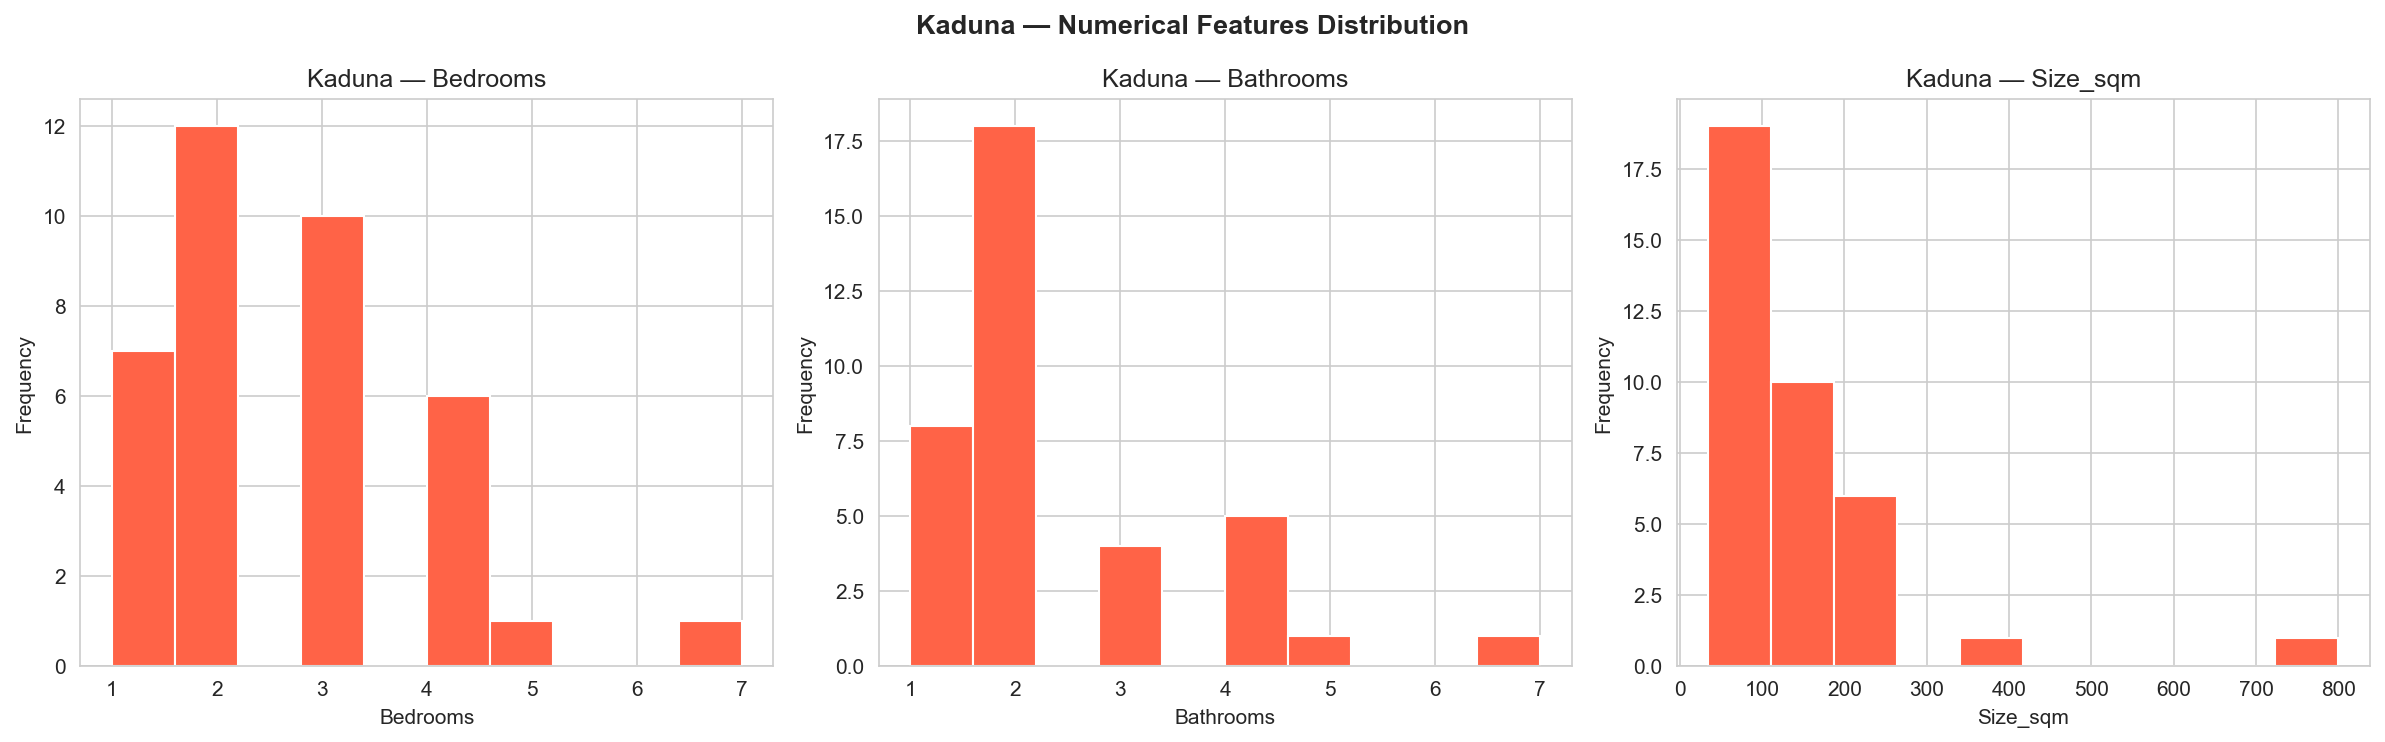

Chart saved.


In [20]:
numerical_kaduna = ['Bedrooms', 'Bathrooms', 'Size_sqm']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(numerical_kaduna):
    axes[i].hist(
        kaduna_raw[col].dropna(),
        bins=10,
        color='tomato',
        edgecolor='white')
    axes[i].set_title(f"Kaduna — {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.suptitle(
    "Kaduna — Numerical Features Distribution",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_kaduna_numerical.png", dpi=150)
plt.show()
print("Chart saved.")

 Correlation Heatmap Kaduna

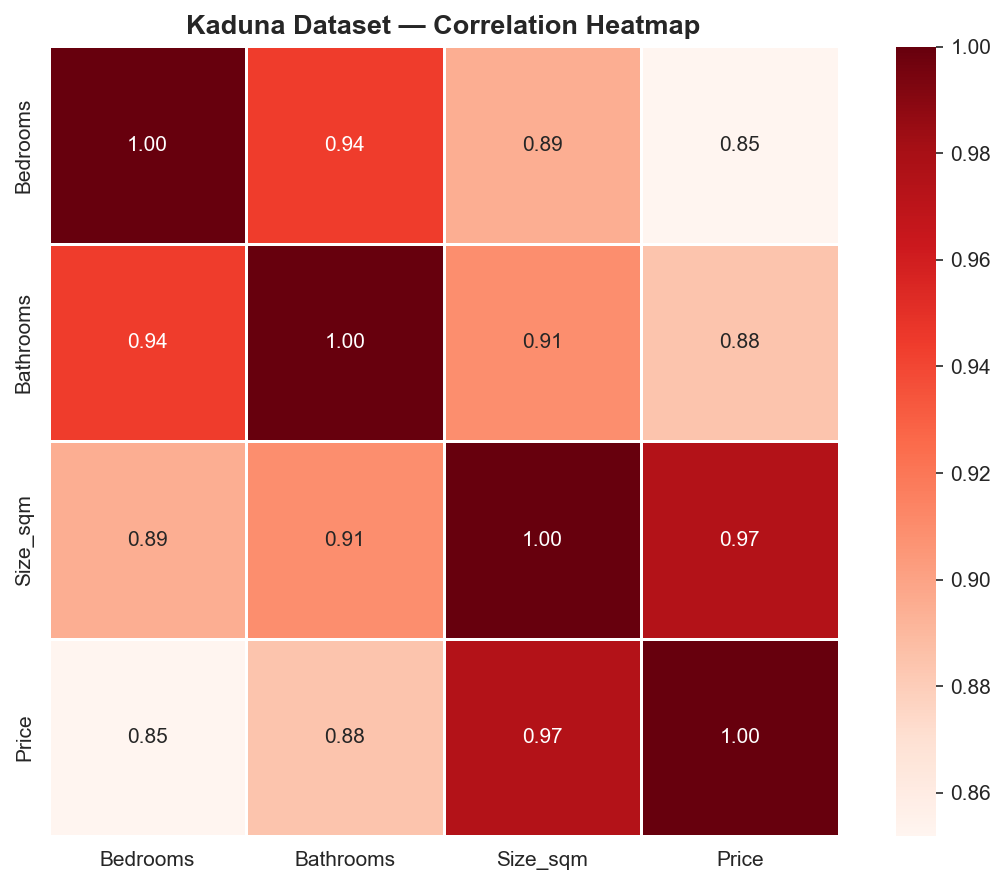

Chart saved.


In [24]:
kaduna_num = kaduna_raw[
    ['Bedrooms', 'Bathrooms',
     'Size_sqm', 'Price']].dropna()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    kaduna_num.corr(),
    annot=True,
    fmt='.2f',
    cmap='Reds',
    ax=ax,
    linewidths=0.5,
    square=True)

ax.set_title(
    "Kaduna Dataset — Correlation Heatmap",
    fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig("eda_kaduna_correlation.png", dpi=150)
plt.show()
print("Chart saved.")

 check what Size column actually contains:
python

In [29]:
print("Size column sample:")
print(malaysia_raw['Size'].head(20))
print("\nSize data type:", malaysia_raw['Size'].dtype)
print("\nSize_clean valid values:")
print(malaysia_raw['Size_clean'].dropna().head(10))
print(f"Size_clean valid count: {malaysia_raw['Size_clean'].dropna().shape[0]}")

Size column sample:
0        Built-up : 1,335 sq. ft.
1        Land area : 6900 sq. ft.
2        Built-up : 1,875 sq. ft.
3                             NaN
4        Built-up : 1,513 sq. ft.
5        Land area : 7200 sq. ft.
6                             NaN
7        Land area : 3600 sq. ft.
8       Land area : 25x75 sq. ft.
9          Built-up : 904 sq. ft.
10                            NaN
11    Land area : 22 x 80 sq. ft.
12       Land area : 1900 sq. ft.
13       Land area : 6000 sq. ft.
14                            NaN
15       Land area : 3600 sq. ft.
16       Land area : 8500 sq. ft.
17       Built-up : 4,842 sq. ft.
18       Built-up : 1,830 sq. ft.
19       Built-up : 3,720 sq. ft.
Name: Size, dtype: str

Size data type: str

Size_clean valid values:
Series([], Name: Size_clean, dtype: float64)
Size_clean valid count: 0


 Price vs Features Scatter Malaysia

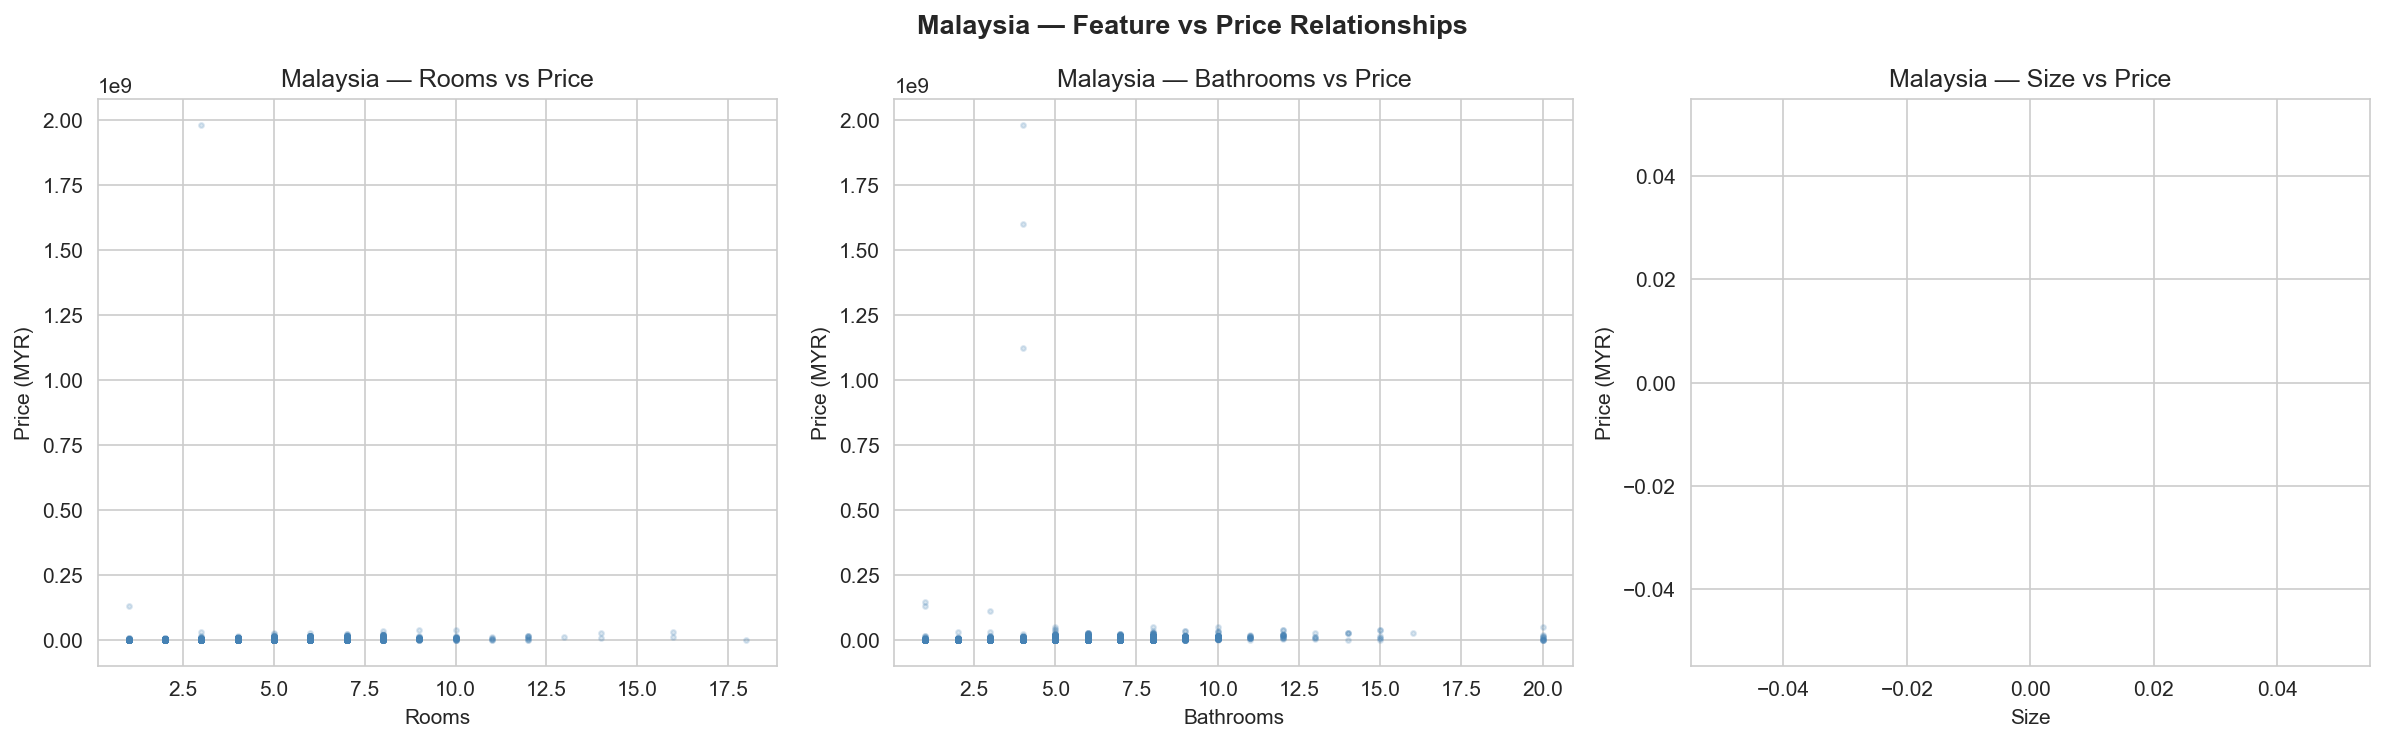

Chart saved.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Use cleaned numeric columns
cols = {
    'Rooms':    'Rooms_clean',
    'Bathrooms':'Bathrooms',
    'Size':     'Size_clean'
}

for i, (label, col) in enumerate(cols.items()):
    axes[i].scatter(
        malaysia_raw[col],
        malaysia_raw['Price_clean'],
        alpha=0.2,
        color='steelblue',
        s=5)
    axes[i].set_title(
        f"Malaysia — {label} vs Price")
    axes[i].set_xlabel(label)
    axes[i].set_ylabel("Price (MYR)")

plt.suptitle(
    "Malaysia — Feature vs Price Relationships",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_malaysia_scatter.png", dpi=150)
plt.show()
print("Chart saved.")

Price vs Features Scatter Kaduna

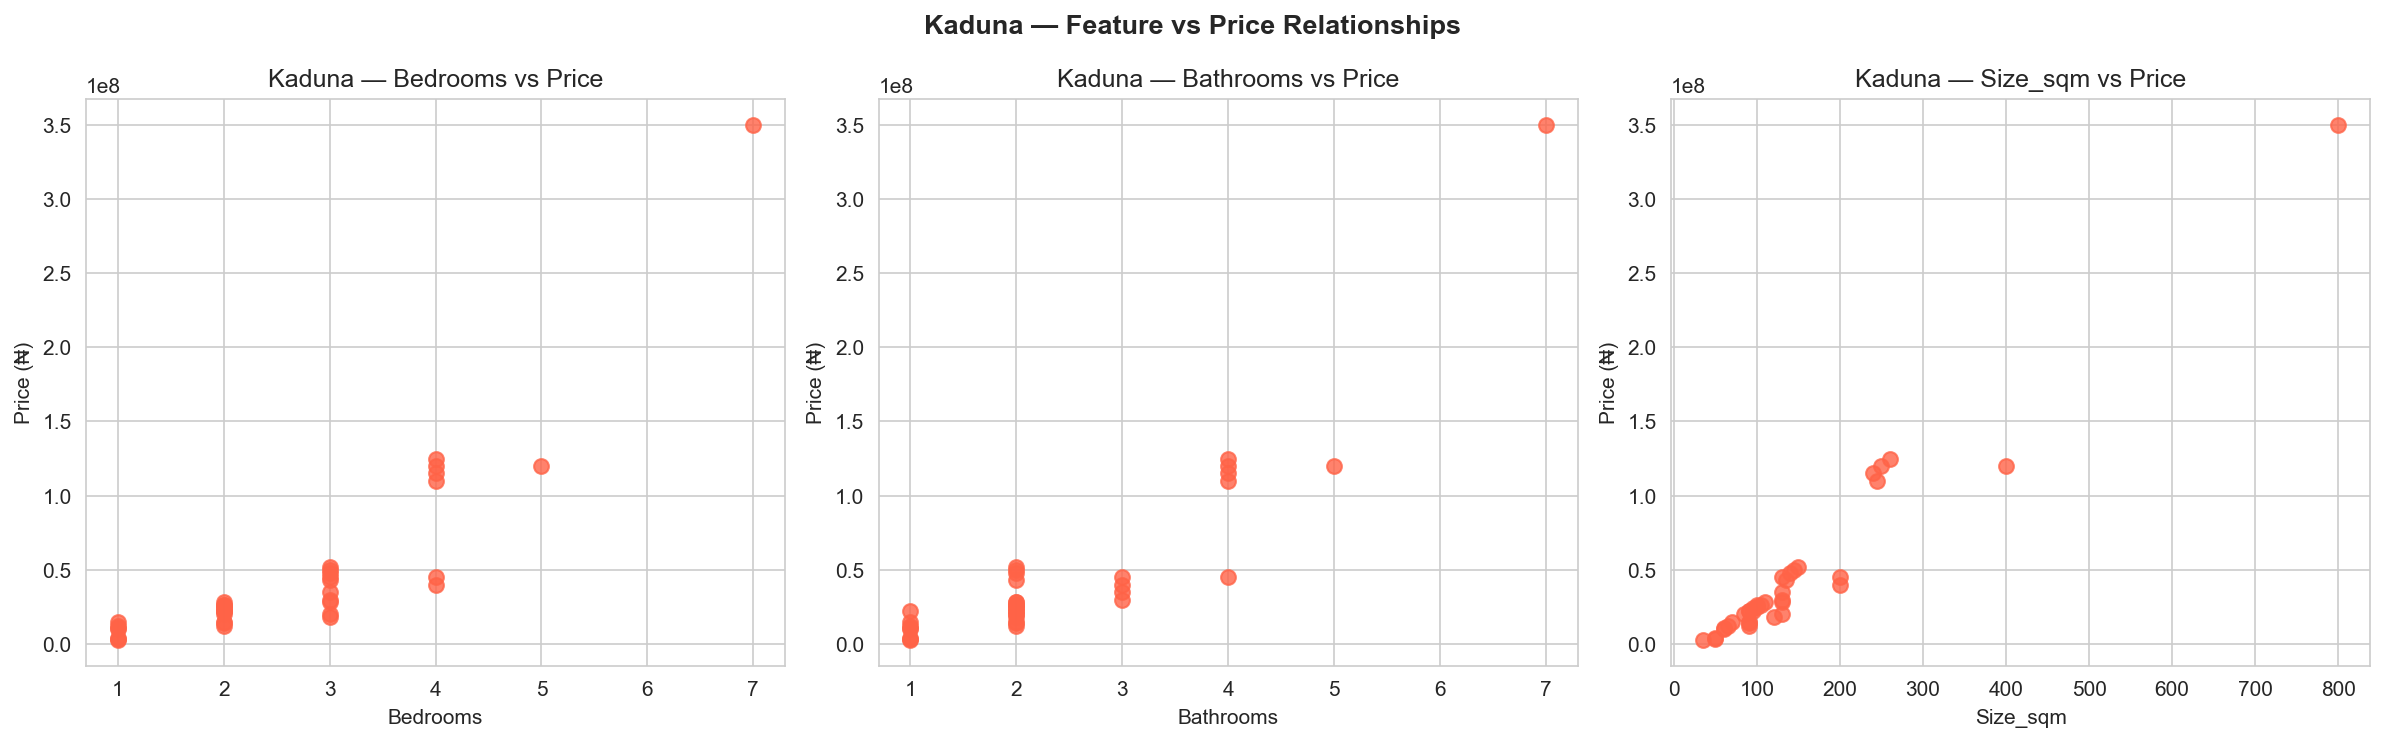

Chart saved.


In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(
        ['Bedrooms', 'Bathrooms', 'Size_sqm']):
    axes[i].scatter(
        kaduna_raw[col],
        kaduna_raw['Price'],
        alpha=0.8,
        color='tomato',
        s=50)
    axes[i].set_title(
        f"Kaduna — {col} vs Price")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Price (₦)")

plt.suptitle(
    "Kaduna — Feature vs Price Relationships",
    fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("eda_kaduna_scatter.png", dpi=150)
plt.show()
print("Chart saved.")

Final Dataset Comparison Summary

In [36]:
print("=" * 60)
print("         DATASET COMPARISON SUMMARY")
print("=" * 60)

# Use only original columns for Malaysia
malaysia_original_cols = [
    'Location', 'Price', 'Rooms', 'Bathrooms',
    'Car Parks', 'Property Type', 'Size', 'Furnishing'
]

malaysia_original = malaysia_raw[
    malaysia_original_cols].copy()

comparison = pd.DataFrame({
    'Attribute': [
        'Total Records',
        'Total Features',
        'Price Currency',
        'Price Minimum',
        'Price Maximum',
        'Price Mean',
        'Price Median',
        'Missing Values',
        'Has Location',
        'Extra Features'
    ],
    'Malaysia': [
        f"{len(malaysia_original):,}",
        malaysia_original.shape[1],
        'MYR (Ringgit)',
        f"RM {malaysia_raw['Price_clean'].min():,.0f}",
        f"RM {malaysia_raw['Price_clean'].max():,.0f}",
        f"RM {malaysia_raw['Price_clean'].mean():,.0f}",
        f"RM {malaysia_raw['Price_clean'].median():,.0f}",
        malaysia_original.isnull().sum().sum(),
        'Yes',
        'Car Parks, Furnishing'
    ],
    'Kaduna South': [
        f"{len(kaduna_raw):,}",
        kaduna_raw.shape[1],
        'Naira (₦)',
        f"₦{kaduna_raw['Price'].min():,.0f}",
        f"₦{kaduna_raw['Price'].max():,.0f}",
        f"₦{kaduna_raw['Price'].mean():,.0f}",
        f"₦{kaduna_raw['Price'].median():,.0f}",
        kaduna_raw.isnull().sum().sum(),
        'Yes',
        'LGA, Security, Flood Risk, Proximity'
    ]
})

print(comparison.to_string(index=False))
print("\n" + "=" * 60)
print("EDA Complete.")
print("=" * 60)

         DATASET COMPARISON SUMMARY
     Attribute              Malaysia                         Kaduna South
 Total Records                53,883                                   37
Total Features                     8                                   11
Price Currency         MYR (Ringgit)                            Naira (₦)
 Price Minimum                 RM 10                           ₦2,500,000
 Price Maximum      RM 1,980,000,000                         ₦350,000,000
    Price Mean          RM 2,091,947                          ₦46,162,162
  Price Median            RM 990,000                          ₦26,000,000
Missing Values                 29552                                    0
  Has Location                   Yes                                  Yes
Extra Features Car Parks, Furnishing LGA, Security, Flood Risk, Proximity

EDA Complete.
